# Held-out validation of the MSTX-style hedge

`mstx_style_hedge_sandbox.ipynb` reports strong numbers (10% OTM, hr=0.5: CAGR 43.2%,
Sharpe 1.75, MaxDD -11.6%) -- but like every other result produced today, they're a
single full-period run (2022-08-09 -> 2026-06-10), never checked against a window it
wasn't measured on. This notebook doesn't change the strategy at all -- `simulate_mstx_style`
below is copied unchanged from that notebook's cell 5, just parametrized to accept a date
window instead of always running the full history -- and runs it through the same
train/testA/testB/continuous-out-of-train harness used for the CBA ensemble candidates in
`holdout_validation_sandbox.ipynb`.

One honest caveat carried over unchanged from the source notebook: no transaction costs
or borrow rate are modeled here (unlike `cba_backtest.py`'s `simulate_ensemble`) -- this
is a frictionless replication of the MSTX methodology, not a cost-aware one. With only
~1 roll per quarter that's a much smaller omission than it would be for a high-turnover
strategy, but it's still an omission, noted here rather than silently carried forward.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve().parents[1]  # scripts/utils/ -> project root
sys.path.insert(0, str(ROOT / "scripts" / "eda"))
sys.path.insert(0, str(ROOT / "scripts" / "backtest"))

from data_loader import load_tsla_underlying, load_tsll, load_tsla_calls
from options_selection import select_contract, bs_delta
from metrics import summarize

%matplotlib inline

TARGET_DTE = 90
ROLL_DTE = 21
MAX_DTE = 130
HEDGE_RATIO = 0.5
TSLL_LEVER = 2.0
R_RF = 0.05
VOL_WINDOW = 21
print("Imports OK")

Imports OK


## Load data (identical to `mstx_style_hedge_sandbox.ipynb`)

In [2]:
tsll_spot = load_tsll().set_index("Date")["Close"]
tsla_spot = load_tsla_underlying().set_index("Date")["Close"].reindex(tsll_spot.index).ffill()
tsla_sigma = (tsla_spot.pct_change().rolling(VOL_WINDOW).std() * (252 ** 0.5)).ffill().bfill()

tsla_calls = load_tsla_calls()
tsla_lookup = tsla_calls.set_index(["raw_id", "date"])["px_last"].to_dict()

dates = tsll_spot.index
print(f"Full window: {len(dates):,} trading days, {dates.min().date()} -> {dates.max().date()}")

Full window: 963 trading days, 2022-08-09 -> 2026-06-10


## Windows -- same dates used for the CBA ensemble holdout check

In [3]:
TRAIN_START = pd.Timestamp("2022-09-09")
TRAIN_END   = pd.Timestamp("2023-01-03")
TEST_A_START = pd.Timestamp("2024-12-17")   # decline
TEST_A_END   = pd.Timestamp("2025-04-08")
TEST_B_START = pd.Timestamp("2025-04-08")   # rally
TEST_B_END   = pd.Timestamp("2025-12-16")

WINDOWS = {
    "train": dates[(dates >= TRAIN_START) & (dates <= TRAIN_END)],
    "testA": dates[(dates >= TEST_A_START) & (dates <= TEST_A_END)],
    "testB": dates[(dates >= TEST_B_START) & (dates <= TEST_B_END)],
    "continuous_out_of_train": dates[dates > TRAIN_END],
}
for name, w in WINDOWS.items():
    print(f"{name:>24s}: {len(w):4d} days, {w.min().date()} -> {w.max().date()}")

                   train:   80 days, 2022-09-09 -> 2023-01-03
                   testA:   76 days, 2024-12-17 -> 2025-04-08
                   testB:  175 days, 2025-04-08 -> 2025-12-16
 continuous_out_of_train:  861 days, 2023-01-04 -> 2026-06-10


## `simulate_mstx_style` -- unchanged from the source notebook, just takes `sim_dates`

In [4]:
def simulate_mstx_style(sim_dates, moneyness_bucket, notional=1.0, hedge_ratio=HEDGE_RATIO):
    """Static short TSLL + rolling TSLA call, sized to hedge_ratio x full delta-neutral
    coverage AT THE FIXED notional (never resized to a growing exposure target -- this is
    the mechanism that avoids the runaway/negative-equity feedback loop seen in every other
    config tested today), rolled on a calendar DTE trigger only."""
    S_incep = float(tsll_spot.loc[sim_dates[0]])
    n_shares = notional / S_incep

    short_pnl = 0.0
    option_pnl = 0.0
    position = None
    S_prev = S_incep
    n_rolls = 0

    equity = pd.Series(index=sim_dates, dtype=float)

    def mtm(pos, date):
        if date > pos["expiry"]:
            return max(float(tsla_spot.loc[date]) - pos["strike"], 0.0)
        px = tsla_lookup.get((pos["raw_id"], date))
        return float(px) if px is not None and pd.notna(px) else pos["price"]

    def open_position(d):
        row = select_contract(tsla_calls, tsla_spot, d, moneyness_bucket, TARGET_DTE, max_dte=MAX_DTE)
        if row is None:
            return None
        S_tsla = float(tsla_spot.loc[d])
        sigma = float(tsla_sigma.loc[d]) if d in tsla_sigma.index else 0.5
        T = max((row["expiry"] - d).days / 365.25, 1 / 365)
        delta = bs_delta(S_tsla, float(row["strike"]), T, R_RF, sigma)
        n = hedge_ratio * TSLL_LEVER * notional / (max(delta, 0.01) * 100 * S_tsla)
        return {"raw_id": row["raw_id"], "strike": float(row["strike"]), "expiry": row["expiry"],
                "n": n, "price": float(row["px_last"])}

    for d in sim_dates:
        S_today = float(tsll_spot.loc[d])
        short_pnl += n_shares * (S_prev - S_today)
        S_prev = S_today

        if position is not None:
            px = mtm(position, d)
            option_pnl += position["n"] * 100 * (px - position["price"])
            position["price"] = px

        held_dte = (position["expiry"] - d).days if position is not None else -1
        need_roll = position is None or held_dte < ROLL_DTE

        if need_roll:
            new_pos = open_position(d)
            if new_pos is not None:
                position = new_pos
                n_rolls += 1

        equity.loc[d] = notional + short_pnl + option_pnl

    return equity, n_rolls

## Run S1 (unhedged) + 10% OTM + 20% OTM across every window

In [5]:
def static_short_equity(sim_dates, notional=1.0):
    S_incep = float(tsll_spot.loc[sim_dates[0]])
    n_shares = notional / S_incep
    eq = pd.Series(index=sim_dates, dtype=float)
    S_prev = S_incep
    pnl = 0.0
    for d in sim_dates:
        S_today = float(tsll_spot.loc[d])
        pnl += n_shares * (S_prev - S_today)
        S_prev = S_today
        eq.loc[d] = notional + pnl
    return eq

curves = {}
rows = []
for win_name, win_dates in WINDOWS.items():
    curves[win_name] = {}

    eq_s1 = static_short_equity(win_dates)
    curves[win_name]["S1 unhedged"] = eq_s1
    row = summarize(eq_s1, eq_s1.pct_change().dropna(), "S1 unhedged short")
    row["window"] = win_name
    row["rolls"] = None
    rows.append(row)

    for bucket in ["10% OTM", "20% OTM"]:
        for hr in [0.5, 1.0]:
            eq, n_rolls = simulate_mstx_style(win_dates, bucket, hedge_ratio=hr)
            label = f"Short TSLL + {bucket} TSLA call (hr={hr})"
            curves[win_name][label] = eq
            row = summarize(eq, eq.pct_change().dropna(), label)
            row["window"] = win_name
            row["rolls"] = n_rolls
            rows.append(row)

results_df = pd.DataFrame(rows)[["Strategy", "window", "CAGR", "Ann. Vol", "Sharpe", "Max DD", "Calmar", "rolls"]]
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
results_df

,Strategy,window,CAGR,Ann. Vol,Sharpe,Max DD,Calmar,rolls
0,S1 unhedged short,train,5.406016,0.430713,4.593170,-0.079465,68.029935,NaN
1,Short TSLL + 10% OTM TSLA call (hr=0.5),train,2.008578,0.320572,3.645414,-0.074575,26.933738,2.0
2,Short TSLL + 10% OTM TSLA call (hr=1.0),train,0.110714,0.407916,0.461362,-0.205710,0.538205,2.0
3,Short TSLL + 20% OTM TSLA call (hr=0.5),train,2.060388,0.397260,3.051909,-0.084290,24.444036,7.0
4,Short TSLL + 20% OTM TSLA call (hr=1.0),train,0.163745,0.502140,0.551520,-0.176163,0.929510,7.0
5,S1 unhedged short,testA,6.184284,0.542986,4.019396,-0.119517,51.743941,NaN
6,Short TSLL + 10% OTM TSLA call (hr=0.5),testA,1.953827,0.376016,3.158939,-0.088408,22.100178,2.0
7,Short TSLL + 10% OTM TSLA call (hr=1.0),testA,-0.132905,0.481022,-0.070322,-0.174305,-0.762488,2.0
8,Short TSLL + 20% OTM TSLA call (hr=0.5),testA,2.173072,0.418622,3.045128,-0.076046,28.575605,2.0
9,Short TSLL + 20% OTM TSLA call (hr=1.0),testA,0.063635,0.533034,0.373431,-0.217393,0.292716,2.0


## Equity curves, per window

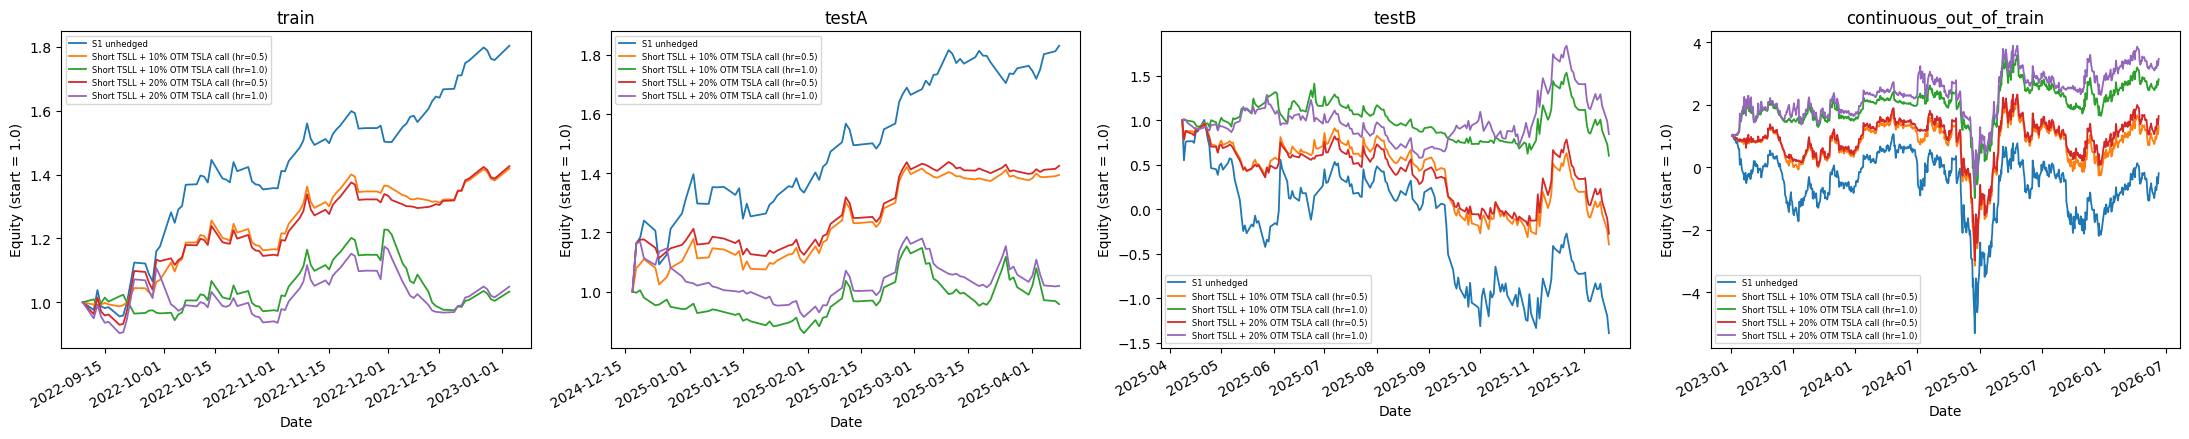

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))
for ax, win_name in zip(axes, WINDOWS.keys()):
    for label, eq in curves[win_name].items():
        eq.plot(ax=ax, label=label, linewidth=1.3)
    ax.set_title(win_name)
    ax.set_ylabel("Equity (start = 1.0)")
    ax.legend(fontsize=6)
fig.tight_layout()
plt.show()

## Sanity checks

In [7]:
for win_name, per_label in curves.items():
    for label, eq in per_label.items():
        assert eq.isna().sum() == 0, f"{win_name} / {label}: equity has NaNs"
        # S1 (unhedged) is a naked short on a leveraged ETF over multi-year windows --
        # unbounded loss is real, expected behavior, not a bug. Only flag the HEDGED
        # variants going implausibly negative (that WOULD indicate a bug, same class as
        # the negative-equity issue found in the from-scratch rebuild earlier today).
        if "unhedged" not in label:
            assert eq.min() > -5.0, f"{win_name} / {label}: equity fell to an implausible level ({eq.min():.2f})"

print("Sanity checks passed (S1 unhedged is allowed to go deeply negative -- that's real, not a bug).")
print("\nFull comparison:")
print(results_df.to_string(index=False))

Sanity checks passed (S1 unhedged is allowed to go deeply negative -- that's real, not a bug).

Full comparison:
                               Strategy                  window      CAGR   Ann. Vol    Sharpe    Max DD    Calmar  rolls
                      S1 unhedged short                   train  5.406016   0.430713  4.593170 -0.079465 68.029935    NaN
Short TSLL + 10% OTM TSLA call (hr=0.5)                   train  2.008578   0.320572  3.645414 -0.074575 26.933738    2.0
Short TSLL + 10% OTM TSLA call (hr=1.0)                   train  0.110714   0.407916  0.461362 -0.205710  0.538205    2.0
Short TSLL + 20% OTM TSLA call (hr=0.5)                   train  2.060388   0.397260  3.051909 -0.084290 24.444036    7.0
Short TSLL + 20% OTM TSLA call (hr=1.0)                   train  0.163745   0.502140  0.551520 -0.176163  0.929510    7.0
                      S1 unhedged short                   testA  6.184284   0.542986  4.019396 -0.119517 51.743941    NaN
Short TSLL + 10% OTM TSLA call (h